In [66]:
import pandas as pd

df = pd.read_csv("Domestic violence.csv")
df

,SL. No,Age,Education,Employment,Income,Marital status,Violence
0,1,30,secondary,unemployed,0,married,yes
1,2,47,tertiary,unemployed,0,married,no
2,3,24,tertiary,unemployed,0,unmarred,no
3,4,22,tertiary,unemployed,0,unmarred,no
4,5,50,primary,unemployed,0,married,yes
...,...,...,...,...,...,...,...
342,343,27,tertiary,semi employed,30000,unmarred,no
343,344,26,tertiary,employed,35000,married,no
344,345,27,primary,unemployed,0,married,yes
345,346,29,primary,unemployed,0,married,no


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   SL. No           347 non-null    int64 
 1   Age              347 non-null    int64 
 2   Education        347 non-null    object
 3   Employment       347 non-null    object
 4   Income           347 non-null    int64 
 5   Marital status   347 non-null    object
 6   Violence         347 non-null    object
dtypes: int64(3), object(4)
memory usage: 19.1+ KB


In [68]:
df.describe()

,SL. No,Age,Income
count,347.000000,347.000000,347.000000
mean,174.000000,31.380403,2110.685879
std,100.314505,9.601569,5743.278766
min,1.000000,15.000000,0.000000
25%,87.500000,23.000000,0.000000
50%,174.000000,30.000000,0.000000
75%,260.500000,39.500000,0.000000
max,347.000000,60.000000,35000.000000


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df = df.drop("SL. No", axis = 1) #axis = 1, takes the column instead of rows. 0 = axis of(search by) rows, 1 = axis of columns
df

,Age,Education,Employment,Income,Marital status,Violence
0,30,secondary,unemployed,0,married,yes
1,47,tertiary,unemployed,0,married,no
2,24,tertiary,unemployed,0,unmarred,no
3,22,tertiary,unemployed,0,unmarred,no
4,50,primary,unemployed,0,married,yes
...,...,...,...,...,...,...
342,27,tertiary,semi employed,30000,unmarred,no
343,26,tertiary,employed,35000,married,no
344,27,primary,unemployed,0,married,yes
345,29,primary,unemployed,0,married,no


In [71]:
df.duplicated().sum() 
# cek lagi after dropping one column, the remaining other columns could be the same - 
# because it was the dropped column that could have differentiate it in the beginning
# up to the DS if you want to remove duplicates or not - 
# another option is to do two analysis, with dropped and with no dropped

np.int64(133)

In [72]:
df.columns

Index(['Age', 'Education ', 'Employment ', 'Income', 'Marital status ',
       'Violence '],
      dtype='object')

In [73]:
df.columns = ["age","education","employment","income","marital_status","violence"] # rename columns
df

,age,education,employment,income,marital_status,violence
0,30,secondary,unemployed,0,married,yes
1,47,tertiary,unemployed,0,married,no
2,24,tertiary,unemployed,0,unmarred,no
3,22,tertiary,unemployed,0,unmarred,no
4,50,primary,unemployed,0,married,yes
...,...,...,...,...,...,...
342,27,tertiary,semi employed,30000,unmarred,no
343,26,tertiary,employed,35000,married,no
344,27,primary,unemployed,0,married,yes
345,29,primary,unemployed,0,married,no


In [74]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 30)


Column: age
[30 47 24 22 50 21 27 20 18 40 45 43 15 44 35 23 19 25 32 26 37 33 42 54
 34 39 29 51 28 46 55 36 38 56 60 17 31 41 48]
------------------------------
Column: education
['secondary' 'tertiary' 'primary' 'none']
------------------------------
Column: employment
['unemployed' 'semi employed' 'employed' 'employed ']
------------------------------
Column: income
[    0     8  1000  1200  1500  2000  2200  2500  3000  3500  4000  5000
  5500  6000  7000  8000  9000 10000 12000 15000 18000 20000 22000 24000
 25000 27000 28000 30000 35000]
------------------------------
Column: marital_status
['married' 'unmarred']
------------------------------
Column: violence
['yes' 'no']
------------------------------


In [75]:
df["employment"] = df["employment"].str.strip()


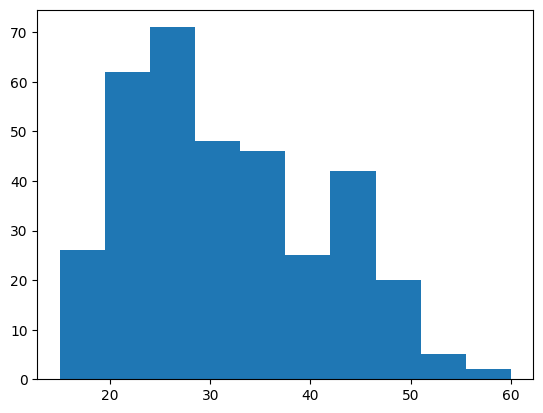

In [76]:
## EDA

import matplotlib.pyplot as plt
import seaborn as sns

# Age EDA
plt.hist(df["age"])
plt.show()

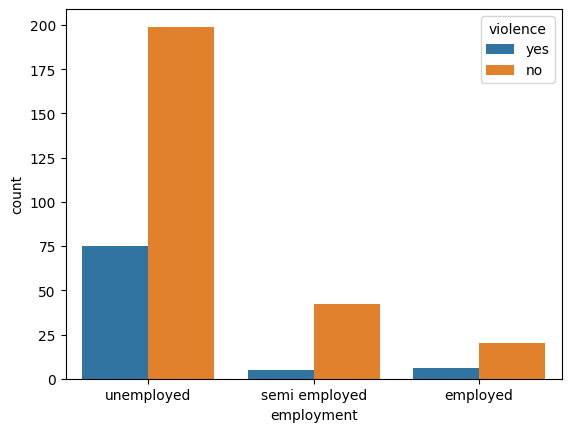

In [77]:
# Education
sns.countplot(x="employment", hue = "violence", data=df)
plt.show()

In [78]:
pie = list(df["violence"].value_counts())
pie

[261, 86]

([<matplotlib.patches.Wedge at 0x168844410>,
 [Text(-0.7830809981377986, 0.7725180582714615, 'no'),
  Text(0.7830812498560911, -0.7725178031112439, 'yes')],
 [Text(-0.42713508989334464, 0.4213734863298881, '75.2%'),
  Text(0.4271352271942314, -0.42137334715158753, '24.8%')])

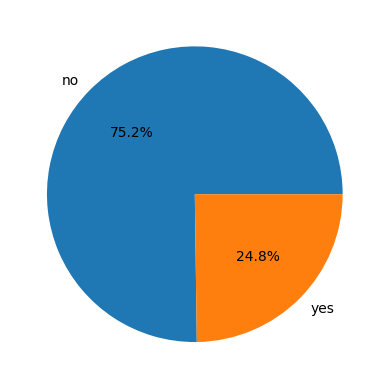

In [79]:
plt.pie(pie, labels = ["no","yes"], autopct = "%1.1f%%") # becareful of the order
# "/%width.precisionType%" width = space yg perlu (ga ngaruh), precision = decimal point, 
# Type = f for float, d for interger, s for string, % = symbol used

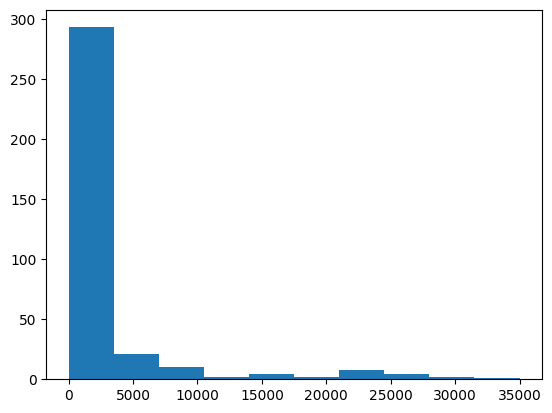

In [80]:
# EDA Income
plt.hist(df["income"])
plt.show()

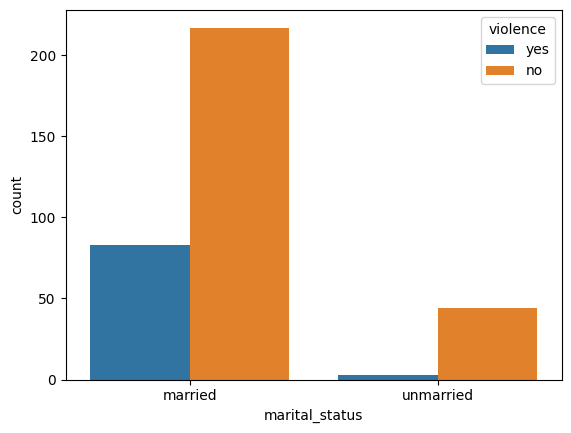

In [81]:
#Conditional changes => mengubah value dgn condition tertentu
df.loc[df["marital_status"] == "unmarred", "marital_status"]= "unmarried"

# Marital Status
sns.countplot(x="marital_status", hue = "violence", data=df)
plt.show()


In [82]:
df_corr = df[["age","income"]] 
df_corr.corr()

,age,income
age,1.000000,0.055338
income,0.055338,1.000000


In [83]:
# Encode manually to ensure labels are as expected

# Marital_status column
df["marital_status"] = df["marital_status"].replace({
    "married": 1,
    "unmarried": 0
})

# Employment column
df["employment"] = df["employment"].replace({
    "unemployed": 0,
    "employed": 1,
    "semi employed": 2
})

# Education

df["education"] = df["education"].replace({
    "none": 0,
    "primary": 1,
    "secondary": 2,
    "tertiary": 3
})

# Violence
df["violence"] = df["violence"].replace({
    "no": 0,
    "yes": 1
})

/var/folders/v1/xk0crw955bv41yhqx2vb3nlr0000gn/T/ipykernel_1559/1250697712.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["marital_status"] = df["marital_status"].replace({
/var/folders/v1/xk0crw955bv41yhqx2vb3nlr0000gn/T/ipykernel_1559/1250697712.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["employment"] = df["employment"].replace({
/var/folders/v1/xk0crw955bv41yhqx2vb3nlr0000gn/T/ipykernel_1559/1250697712.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future vers

In [17]:
# cara lain: convert other columns to numeric first before calculating correlation

#from sklearn.preprocessing import LabelEncoder

#columns_to_encode = ["education", "employment", "marital_status", "violence"]

#encoder = LabelEncoder()

#for col in columns_to_encode:
   # df[col] = encoder.fit_transform(df[col]) 

# label encoder => correlation => plot
# belajar SMOTE biar ga bias
# Logistic Regression and Random Forest 

In [84]:
df

,age,education,employment,income,marital_status,violence
0,30,2,0,0,1,1
1,47,3,0,0,1,0
2,24,3,0,0,0,0
3,22,3,0,0,0,0
4,50,1,0,0,1,1
...,...,...,...,...,...,...
342,27,3,2,30000,0,0
343,26,3,1,35000,1,0
344,27,1,0,0,1,1
345,29,1,0,0,1,0


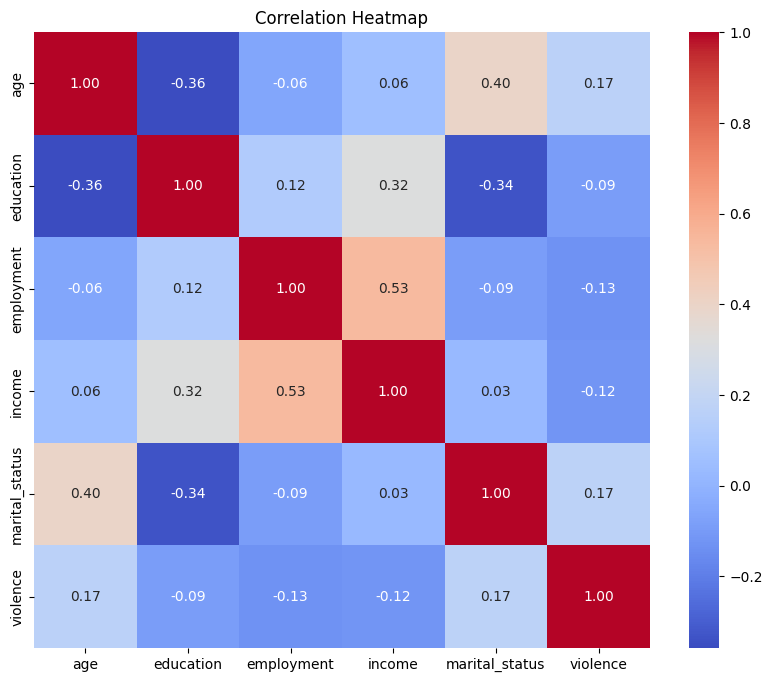

In [85]:
# Correlation
corr_matrix = df.corr()

#Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

In [94]:
# Scaling age and income
from sklearn.preprocessing import StandardScaler

# Create a scaler
scaler = StandardScaler()

# Scale only the numeric columns
df[["income", "age"]] = scaler.fit_transform(df[["income", "age"]])


In [95]:
# Using SMOTE for binary class imbalance
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [96]:
#Split data

X = df.drop("violence", axis=1)  # Features
y = df["violence"]               # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [97]:
# Apply balancing with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [98]:
#Check if SMOTE worked

from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_resampled))

Before SMOTE: Counter({0: 208, 1: 69})
After SMOTE: Counter({0: 208, 1: 208})


In [99]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_resampled, y_resampled)  # Use SMOTE-resampled data
y_pred = model.predict(X_test)

In [100]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.4857142857142857

Confusion Matrix:
 [[20 33]
 [ 3 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.38      0.53        53
           1       0.30      0.82      0.44        17

    accuracy                           0.49        70
   macro avg       0.58      0.60      0.48        70
weighted avg       0.73      0.49      0.50        70



In [101]:
# Accuracy: proportion of correct predictions - very low at 48% predicted correctly
# Confusion matrix: we have a big number of false positive
# Classification report: High recall meaning lower false negative rate but 
# precision is low meaning high false positive rate as shown in confusion matrix score

In [122]:
# Hyperparameter tuning Logistic

# Define a grid of hyperparamtere 'params_rf'
params_log = {
                'C': [1,10,100,1000],
                'solver': ['saga','lbfgs','liblinear'],
                'max_iter':[2000,4000,6000]
}

# Instantiate 'grid_rf'
grid_log = GridSearchCV(estimator=model,
                       param_grid=params_log,
                       cv=3)

# fit 'grid_rf' to training set
grid_log.fit(X_resampled, y_resampled)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [1, 10, 100, 1000],
                         'max_iter': [2000, 4000, 6000],
                         'solver': ['saga', 'lbfgs', 'liblinear']})

In [124]:
# extract best hyperparameters from 'grid_rf'
best_hyperparams_log = grid_log.best_params_

print('Best hyperparameters:\n', best_hyperparams_log)

Best hyperparameters:
 {'C': 1, 'max_iter': 2000, 'solver': 'saga'}


In [126]:
grid_log.best_score_

np.float64(0.6275327564035728)

In [127]:
#Try with best estimator
best_model_log = grid_log.best_estimator_
y_pred_log = best_model_log.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.4857142857142857
              precision    recall  f1-score   support

           0       0.87      0.38      0.53        53
           1       0.30      0.82      0.44        17

    accuracy                           0.49        70
   macro avg       0.58      0.60      0.48        70
weighted avg       0.73      0.49      0.50        70



In [130]:
model_2 = LogisticRegression(C=1,
                            max_iter=2000, 
                            solver='saga',
                            random_state=42)
model_2.fit(X_resampled, y_resampled)  # Use SMOTE-resampled data
y_pred = model_2.predict(X_test)

In [131]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4857142857142857

Confusion Matrix:
 [[20 33]
 [ 3 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.38      0.53        53
           1       0.30      0.82      0.44        17

    accuracy                           0.49        70
   macro avg       0.58      0.60      0.48        70
weighted avg       0.73      0.49      0.50        70



In [105]:
# Random Forest

# Import packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# set SEED for reproducibility
SEED = 1

In [107]:
# Instantiate a random forest regressor 'rf'
rf = RandomForestClassifier(n_estimators=300,
                               min_samples_leaf = 0.12,
                               random_state=SEED)

# Fit 'rf' to the training set
rf.fit(X_resampled, y_resampled)
# Predict the test set labels 'y_pred'
y_pred = rf.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4142857142857143
              precision    recall  f1-score   support

           0       0.77      0.32      0.45        53
           1       0.25      0.71      0.37        17

    accuracy                           0.41        70
   macro avg       0.51      0.51      0.41        70
weighted avg       0.65      0.41      0.43        70



In [ ]:
# accuracy report for random forest shows that it performs weaker than the logistic regression in all aspects

In [109]:
# Hyperparameter tuning

# Import
from sklearn.model_selection import GridSearchCV

# Define a grid of hyperparamtere 'params_rf'
params_rf = {
                'n_estimators': [100,300,400],
                'min_samples_leaf': [0.10,0.20,0.30],
                'criterion':['gini','entropy','log_loss']
}

# Instantiate 'grid_rf'
grid_rf = GridSearchCV(estimator=rf,
                       param_grid=params_rf,
                       cv=3)

# fit 'grid_rf' to training set
grid_rf.fit(X_resampled, y_resampled)

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(min_samples_leaf=0.12,
                                              n_estimators=300,
                                              random_state=1),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'min_samples_leaf': [0.1, 0.2, 0.3],
                         'n_estimators': [100, 300, 400]})

In [111]:
# extract best hyperparameters from 'grid_rf'
best_hyperparams = grid_rf.best_params_

print('Best hyperparameters:\n', best_hyperparams)

Best hyperparameters:
 {'criterion': 'gini', 'min_samples_leaf': 0.1, 'n_estimators': 400}


In [113]:
grid_rf.best_score_

np.float64(0.6443019497445522)

In [115]:
pd.DataFrame(grid_rf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.067529,0.021341,0.003473,0.000453,gini,0.1,100,"{'criterion': 'gini', 'min_samples_leaf': 0.1,...",0.597122,0.654676,0.637681,0.629827,0.024144,7
1,0.147991,0.005909,0.007343,0.000548,gini,0.1,300,"{'criterion': 'gini', 'min_samples_leaf': 0.1,...",0.589928,0.654676,0.666667,0.637090,0.033706,4
2,0.186748,0.000721,0.009111,0.000145,gini,0.1,400,"{'criterion': 'gini', 'min_samples_leaf': 0.1,...",0.597122,0.661871,0.673913,0.644302,0.033721,1
3,0.046274,0.001187,0.002748,0.000035,gini,0.2,100,"{'criterion': 'gini', 'min_samples_leaf': 0.2,...",0.561151,0.633094,0.630435,0.608226,0.033305,10
4,0.140577,0.002988,0.007041,0.000370,gini,0.2,300,"{'criterion': 'gini', 'min_samples_leaf': 0.2,...",0.561151,0.633094,0.630435,0.608226,0.033305,10
5,0.184648,0.001023,0.008897,0.000098,gini,0.2,400,"{'criterion': 'gini', 'min_samples_leaf': 0.2,...",0.561151,0.633094,0.630435,0.608226,0.033305,10
6,0.048662,0.000682,0.003069,0.000264,gini,0.3,100,"{'criterion': 'gini', 'min_samples_leaf': 0.3,...",0.561151,0.539568,0.528986,0.543235,0.013385,25
7,0.136832,0.000098,0.006853,0.000360,gini,0.3,300,"{'criterion': 'gini', 'min_samples_leaf': 0.3,...",0.561151,0.553957,0.528986,0.548031,0.013784,19
8,0.183255,0.002231,0.008574,0.000089,gini,0.3,400,"{'criterion': 'gini', 'min_samples_leaf': 0.3,...",0.561151,0.553957,0.528986,0.548031,0.013784,19
9,0.047162,0.001074,0.003023,0.000177,entropy,0.1,100,"{'criterion': 'entropy', 'min_samples_leaf': 0...",0.597122,0.647482,0.637681,0.627428,0.021800,8


In [120]:
# extract best model from 'grid_rf'
best_model = grid_rf.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4714285714285714
              precision    recall  f1-score   support

           0       0.79      0.42      0.54        53
           1       0.26      0.65      0.37        17

    accuracy                           0.47        70
   macro avg       0.52      0.53      0.46        70
weighted avg       0.66      0.47      0.50        70



In [ ]:
# why is the scores lower than the ones best_hyperparams spit out? Because the former actually uses X_test 
# whereas the latter uses train data for both train and tesing